# Diffusion models in AI as statistical physics — training a tiny network (1D)

This notebook extends the "exact-score" demo by adding the **learning** step:

- We define the **forward noising process** (DDPM).
- We create training pairs \((x_t, t) \mapsto \varepsilon\) from a simple 1D target distribution.
- We train a small **MLP** to predict the injected noise \(\varepsilon\) (the classic DDPM objective).
- We then **sample** by running a reverse-time Markov chain using the learned model.

Everything is 1D and runs on CPU.

---

## Statistical physics connection (one line)

Forward noising is just a stochastic dynamics that increases entropy.  
Learning \(\varepsilon_\theta(x_t,t)\) gives an estimate of a **score / force-like** object, enabling reverse-time generation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130


## 1) Target distribution: a bimodal mixture

\[
p_0(x) = \tfrac12 \mathcal N(x;\,-m,\sigma_0^2) + \tfrac12 \mathcal N(x;\,+m,\sigma_0^2).
\]

We'll train a diffusion model to learn to generate samples from this distribution.


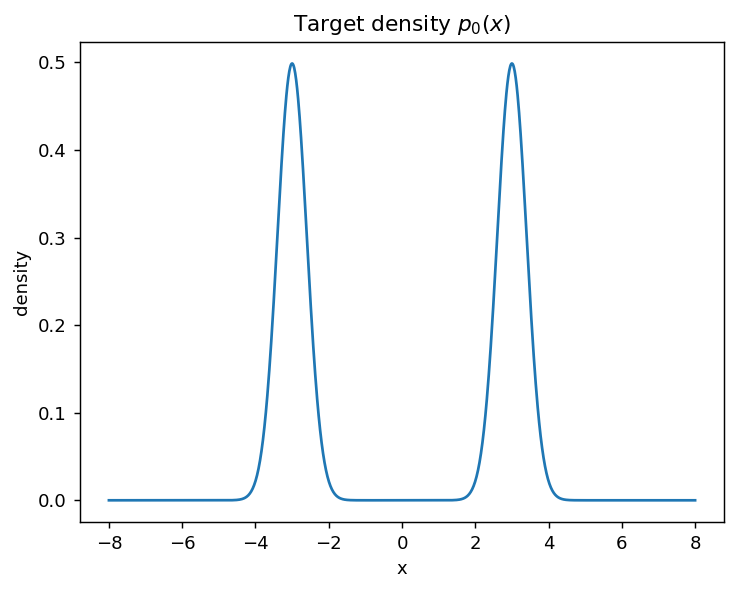

In [2]:
# Target distribution parameters
m = 3.0
sigma0 = 0.4

rng = np.random.default_rng(0)

def sample_p0(n, rng=rng):
    signs = rng.choice([-1.0, +1.0], size=n)
    return signs*m + sigma0*rng.standard_normal(n)

# visualize target
xs = np.linspace(-8, 8, 1200)
def normal_pdf(x, mu, sig):
    return np.exp(-0.5*((x-mu)/sig)**2) / (np.sqrt(2*np.pi)*sig)

p0 = 0.5*normal_pdf(xs, -m, sigma0) + 0.5*normal_pdf(xs, +m, sigma0)

plt.figure()
plt.plot(xs, p0)
plt.title("Target density $p_0(x)$")
plt.xlabel("x"); plt.ylabel("density")
plt.show()


## 2) Forward diffusion (DDPM)

We use the standard discrete forward process:

\[
x_{t+1} = \sqrt{1-\beta_t}\,x_t + \sqrt{\beta_t}\,\varepsilon_t,\qquad \varepsilon_t\sim\mathcal N(0,1).
\]

Closed form:

\[
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\qquad
\bar\alpha_t=\prod_{s=1}^t (1-\beta_s).
\]


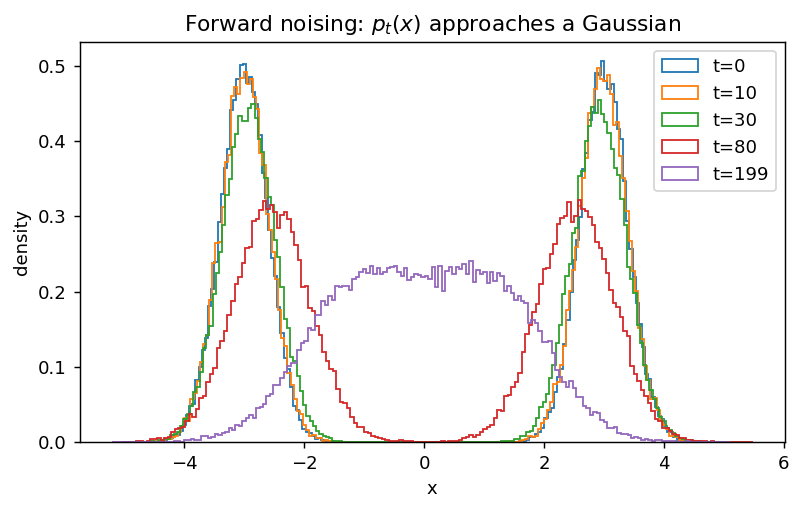

In [3]:
# Diffusion schedule
T = 200
beta = np.linspace(1e-4, 0.02, T).astype(np.float64)
alpha = 1.0 - beta
alpha_bar = np.cumprod(alpha)

def q_sample(x0, t, eps):
    """Sample x_t from q(x_t|x0) using provided eps ~ N(0,1)."""
    ab = alpha_bar[t]
    return np.sqrt(ab)*x0 + np.sqrt(1.0-ab)*eps

# show evolution qualitatively
n = 60000
x0 = sample_p0(n)
ts_show = [0, 10, 30, 80, 199]
plt.figure(figsize=(7,4))
for t in ts_show:
    eps = rng.standard_normal(n)
    xt = q_sample(x0, t, eps)
    plt.hist(xt, bins=180, density=True, histtype="step", label=f"t={t}")
plt.title("Forward noising: $p_t(x)$ approaches a Gaussian")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()


## 3) DDPM training objective: predict the injected noise

A common parameterization is to train \(\varepsilon_\theta(x_t, t)\) to predict the noise used in the forward step:

\[
\min_\theta \; \mathbb E_{x_0\sim p_0,\;t,\;\varepsilon\sim\mathcal N(0,1)}
\left[\|\varepsilon - \varepsilon_\theta(x_t,t)\|^2\right],
\quad x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon.
\]

From \(\varepsilon_\theta\) we can estimate \(x_0\):

\[
\hat x_0(x_t,t) = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\varepsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}.
\]

We'll train a tiny MLP in **PyTorch**.


In [4]:
# PyTorch setup (CPU)
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
except Exception as e:
    raise RuntimeError(
        "This notebook needs PyTorch. Install with e.g. `pip install torch` "
        "(CPU builds are fine). Original import error: " + str(e)
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


/Users/oskarhallatschek/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

### Time embedding

We'll embed the timestep \(t\) with a sinusoidal embedding (as in many diffusion/Transformer models).


In [5]:
def sinusoidal_time_embedding(t, dim=32, max_period=10000.0):
    """t: (batch,) integer tensor in [0, T-1]. returns (batch, dim)."""
    half = dim // 2
    freqs = torch.exp(-np.log(max_period) * torch.arange(0, half, device=t.device) / half)
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
    return emb


### Model: a tiny MLP

Input: \(x_t\) (1D) concatenated with a time embedding.  
Output: predicted noise \(\varepsilon_\theta(x_t,t)\) (1D).


In [6]:
class EpsMLP(nn.Module):
    def __init__(self, tdim=32, h=128):
        super().__init__()
        self.tdim = tdim
        self.net = nn.Sequential(
            nn.Linear(1 + tdim, h),
            nn.SiLU(),
            nn.Linear(h, h),
            nn.SiLU(),
            nn.Linear(h, 1),
        )

    def forward(self, x, t):
        # x: (B,1), t: (B,) int64
        te = sinusoidal_time_embedding(t, dim=self.tdim)
        inp = torch.cat([x, te], dim=1)
        return self.net(inp)

model = EpsMLP(tdim=32, h=128).to(device)
sum(p.numel() for p in model.parameters())


20993

## 4) Training loop

We generate fresh training batches on the fly:
1. sample \(x_0\sim p_0\)
2. sample a time index \(t\)
3. sample \(\varepsilon\sim \mathcal N(0,1)\)
4. build \(x_t\)
5. regress \(\varepsilon\) from \((x_t,t)\).

This is exactly the standard DDPM noise-prediction objective, just in 1D.


In [ ]:
# Training hyperparameters
batch_size = 2048
steps = 2500
lr = 2e-3

opt = torch.optim.AdamW(model.parameters(), lr=lr)

# push schedule to torch once
alpha_bar_torch = torch.from_numpy(alpha_bar).to(device).float()

def sample_batch(batch_size, device=device):
    # x0 from mixture
    x0 = sample_p0(batch_size, rng=rng).astype(np.float32)
    x0 = torch.from_numpy(x0).to(device).view(-1,1)

    # t uniform in {0,...,T-1}
    t = torch.randint(low=0, high=T, size=(batch_size,), device=device, dtype=torch.long)

    # eps ~ N(0,1)
    eps = torch.randn(batch_size, 1, device=device)

    # build xt
    ab = alpha_bar_torch[t].view(-1,1)
    xt = torch.sqrt(ab)*x0 + torch.sqrt(1.0-ab)*eps
    return xt, t, eps

loss_hist = []
for k in range(steps):
    xt, t, eps = sample_batch(batch_size)
    pred = model(xt, t)
    loss = F.mse_loss(pred, eps)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    loss_hist.append(loss.item())
    if (k+1) % 250 == 0:
        print(f"step {k+1:4d}/{steps}  loss={loss.item():.4f}")

plt.figure()
plt.plot(loss_hist)
plt.yscale("log")
plt.title("Training loss (MSE on noise prediction)")
plt.xlabel("step"); plt.ylabel("loss")
plt.show()


step  250/2500  loss=0.5097


## 5) Sampling (reverse process)

To generate, we start from \(x_T \sim \mathcal N(0,1)\) and step backward.

A common DDPM "ancestral" sampler uses the posterior
\[
q(x_{t-1}\mid x_t, x_0) = \mathcal N(\mu_t(x_t,x_0), \tilde\beta_t)
\]
with
\[
\mu_t = \frac{\sqrt{\bar\alpha_{t-1}}\beta_t}{1-\bar\alpha_t}x_0
      + \frac{\sqrt{\alpha_t}(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}x_t,
\quad
\tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t.
\]

We plug in \(\hat x_0(x_t,t)\) from the neural net, obtained via \(\varepsilon_\theta\).


In [ ]:
@torch.no_grad()
def predict_x0(xt, t):
    # xt: (B,1), t: (B,)
    ab = alpha_bar_torch[t].view(-1,1)
    eps_hat = model(xt, t)
    x0_hat = (xt - torch.sqrt(1.0-ab)*eps_hat) / torch.sqrt(ab)
    return x0_hat

@torch.no_grad()
def ddpm_sample(n=50000, device=device):
    x = torch.randn(n, 1, device=device)  # x_T ~ N(0,1)

    alpha_t = torch.from_numpy(alpha).to(device).float()
    beta_t  = torch.from_numpy(beta).to(device).float()
    ab_t    = alpha_bar_torch  # already torch

    for t in reversed(range(T)):
        tt = torch.full((n,), t, device=device, dtype=torch.long)
        x0_hat = predict_x0(x, tt)

        if t == 0:
            x = x0_hat
            break

        ab = ab_t[t]
        ab_prev = ab_t[t-1]
        a = alpha_t[t]
        b = beta_t[t]

        coef1 = torch.sqrt(ab_prev) * b / (1.0 - ab)
        coef2 = torch.sqrt(a) * (1.0 - ab_prev) / (1.0 - ab)
        mu = coef1 * x0_hat + coef2 * x

        beta_tilde = (1.0 - ab_prev) / (1.0 - ab) * b

        x = mu + torch.sqrt(beta_tilde) * torch.randn_like(x)

    return x.squeeze(1).cpu().numpy()

x_gen = ddpm_sample(n=50000)

plt.figure(figsize=(7,4))
plt.hist(sample_p0(50000), bins=180, density=True, histtype="step", label="target $p_0$")
plt.hist(x_gen,           bins=180, density=True, histtype="step", label="generated (trained DDPM)")
plt.title("Sampling with learned $\varepsilon_\theta(x_t,t)$")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()


## 6) Score / force connection (optional but nice)

For Gaussian corruption, DDPM training implies an approximate score:

\[
s_t(x_t) \approx -\frac{1}{\sqrt{1-\bar\alpha_t}}\;\varepsilon_\theta(x_t,t).
\]

In equilibrium stat mech, \(\nabla_x \log p\) is a **force-like** object (e.g. \(-\beta U'(x)\) for Boltzmann weights).  
So \(\varepsilon_\theta\) gives a learned effective force field that makes reverse-time generation possible.


## Exercises / small extensions

1. Change the target distribution (3 modes; asymmetric weights; heavier tails) and retrain.  
2. Try a different schedule (cosine).  
3. Compare this ancestral sampler to a reverse-SDE Euler step (score-based view).  
